In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
base_columns = ["unit_id", "cycle", "setting_1", "setting_2", "setting_3"]
sensor_columns = [f"sensor_{i}" for i in range(1, 21 + 1)]
dataframe = []
column_names = base_columns + sensor_columns
file_path = Path("..")/"data"/"raw"
files = list(sorted(file_path.glob("train_*.txt")))
for file in files:
    result =  pd.read_csv(
        file, 
        sep=r"\s+", 
        header= None , 
        names=column_names, 
        usecols=column_names)
    result["dataset_id"] = file.stem.split("_")[1]
    dataframe.append(result)
df = pd.concat(dataframe,ignore_index=True)
max_cycle = df.groupby(["dataset_id","unit_id"])["cycle"].max().reset_index().rename(columns= {"cycle":"max_cycle"})
df = df.merge(max_cycle,on=["dataset_id","unit_id"])
df["RUL"] = df["max_cycle"] - df["cycle"]
df = df.drop(columns=["max_cycle"])


In [8]:
df.head(
    
)

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,187


In [16]:
fd001 = pd.read_csv(Path("..") / "data" / "raw" / "train_FD001.txt",sep=r"\s+",header=None)
fd001.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [18]:
fd001 = pd.read_csv(Path("..") / "data" / "raw" / "train_FD002.txt",sep=r"\s+",header=None)
fd001.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [4]:
missing_summary = df.isnull().sum().to_frame(name= "missing_values")
type(missing_summary)

pandas.DataFrame

In [12]:
FD001 = df[df["dataset_id"] == "FD003"]
sensor_features = [column for column in df.columns if column.startswith("sensor_")]
correlation = FD001[sensor_features].corrwith(FD001["RUL"]).to_frame("Correlation")
correlation


c:\Users\parde\Downloads\predictive_maintenance_RUL\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\parde\Downloads\predictive_maintenance_RUL\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Correlation
sensor_1,NaN
sensor_2,-5.905638e-01
sensor_3,-6.242357e-01
sensor_4,-6.572239e-01
sensor_5,4.325184e-16
sensor_6,-2.153519e-01
sensor_7,-3.150483e-01
sensor_8,-6.553448e-01
sensor_9,-5.518432e-01
sensor_10,-3.634318e-01


In [9]:
correlation["Absolute_correlation"] = correlation["Correlation"].abs()
correlation
FD001

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,FD001,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,FD001,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,FD001,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,FD001,1


In [7]:
correlation = correlation.sort_values(by= "Absolute_correlation", ascending= False)
correlation

,Correlation,Absolute_correlation
sensor_11,-6.962281e-01,6.962281e-01
sensor_4,-6.789482e-01,6.789482e-01
sensor_12,6.719831e-01,6.719831e-01
sensor_7,6.572227e-01,6.572227e-01
sensor_15,-6.426670e-01,6.426670e-01
sensor_21,6.356620e-01,6.356620e-01
sensor_20,6.294285e-01,6.294285e-01
sensor_2,-6.064840e-01,6.064840e-01
sensor_17,-6.061536e-01,6.061536e-01
sensor_3,-5.845204e-01,5.845204e-01


In [12]:
missing_summary["missing_percentage"] = (missing_summary["missing_values"]/len(df))*100

In [13]:
missing_summary

,missing_values,missing_percentage
unit_id,0,0.0
cycle,0,0.0
setting_1,0,0.0
setting_2,0,0.0
setting_3,0,0.0
sensor_1,0,0.0
sensor_2,0,0.0
sensor_3,0,0.0
sensor_4,0,0.0
sensor_5,0,0.0


In [15]:
missing_summary = missing_summary[missing_summary["missing_values"]>0].sort_values(by = "missing_values",ascending=False)
missing_summary

,missing_values,missing_percentage


In [16]:
if missing_summary.empty:
    print("no missing values")
else:
    print("missing values removed")

no missing values


In [23]:
engine_lifetime = df.groupby(["dataset_id","unit_id"])["cycle"].max()
engine_lifetime

dataset_id  unit_id
FD001       1          192
            2          287
            3          179
            4          189
            5          269
                      ... 
FD004       245        205
            246        161
            247        211
            248        184
            249        255
Name: cycle, Length: 709, dtype: int64

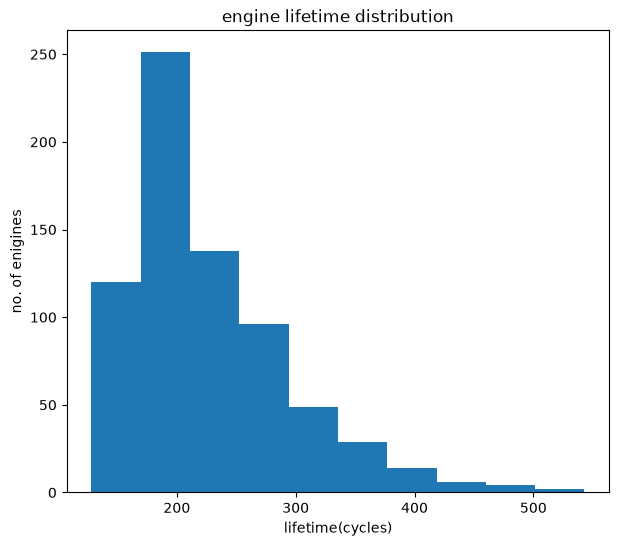

In [ ]:
plt.figure(figsize=(7,6))
plt.hist(engine_lifetime,bins=30)
plt.title("engine lifetime distribution")
plt.xlabel("lifetime(cycles)")
plt.ylabel("no. of enigines")
plt.show()


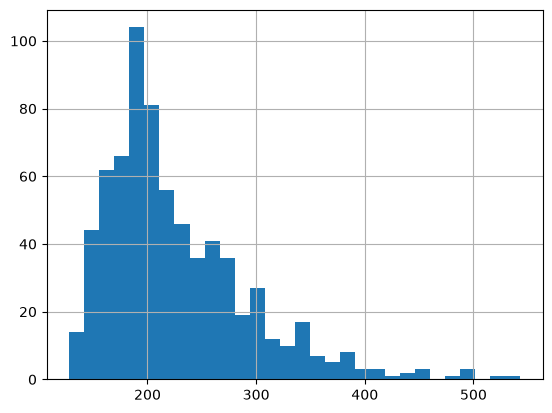

In [37]:
engine_lifetime.hist(bins=30)
plt.show()

In [29]:
!pip  show nbformat

Name: nbformat
Version: 5.10.4
Summary: The Jupyter Notebook format
Home-page: https://jupyter.org
Author: 
Author-email: Jupyter Development Team <jupyter@googlegroups.com>
License: BSD 3-Clause License

- Copyright (c) 2001-2015, IPython Development Team
- Copyright (c) 2015-, Jupyter Development Team

All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior writte

In [5]:
engine_df = df[(df["dataset_id"] == "FD001") & (df["unit_id"] == 1)]
engine_df


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,FD001
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,FD001
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,FD001
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,FD001
